# 03 - Churn Modeling

This notebook builds and evaluates churn prediction models:

1. **Data Preparation**: Train/validation/test splits
2. **Model Training**: Logistic Regression and LightGBM
3. **Model Evaluation**: AUC, precision-recall, business metrics
4. **Interpretability**: Feature importance and SHAP analysis
5. **Model Selection**: Compare and select best model

In [1]:
# Imports
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve

from src.models import ChurnModel, compare_models, print_model_report

# Try to import SHAP
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP not installed. Run: pip install shap")

# Settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

SHAP not installed. Run: pip install shap


## 1. Load Features

In [2]:
# Load engineered features
df = pd.read_parquet('../data/features/churn_features.parquet')
print(f"Loaded {len(df):,} customers with {len(df.columns)} columns")
print(f"Churn rate: {df['churned'].mean():.1%}")

Loaded 5,429 customers with 30 columns
Churn rate: 98.9%


In [3]:
# Separate features and target
feature_cols = [c for c in df.columns if c not in ['visitorid', 'churned']]
X = df[feature_cols]
y = df['churned']

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X):,}")

Features: 28
Samples: 5,429


## 2. Train/Test Split

We use stratified splitting to maintain class balance.

In [4]:
# Split: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # ~15% of total
)

print(f"Training set: {len(X_train):,} ({y_train.mean():.1%} churned)")
print(f"Validation set: {len(X_val):,} ({y_val.mean():.1%} churned)")
print(f"Test set: {len(X_test):,} ({y_test.mean():.1%} churned)")

Training set: 3,801 (98.9% churned)
Validation set: 813 (98.9% churned)
Test set: 815 (98.9% churned)


## 3. Train Models

In [5]:
# Train Logistic Regression baseline
print("Training Logistic Regression...")
lr_model = ChurnModel(model_type='logistic')
lr_model.fit(X_train, y_train, scale_features=True)

# Evaluate on validation
lr_metrics = lr_model.evaluate(X_val, y_val)
print(f"\nLogistic Regression AUC: {lr_metrics.auc_roc:.4f}")

Training Logistic Regression...

Logistic Regression AUC: 0.8599

Logistic Regression AUC: 0.8599


In [6]:
# Train LightGBM model
print("Training LightGBM...")
lgb_model = ChurnModel(model_type='lightgbm')
lgb_model.fit(X_train, y_train, scale_features=False)

# Evaluate on validation
lgb_metrics = lgb_model.evaluate(X_val, y_val)
print(f"\nLightGBM AUC: {lgb_metrics.auc_roc:.4f}")

Training LightGBM...

LightGBM AUC: 0.7942

LightGBM AUC: 0.7942


c:\Users\Calla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [7]:
# Compare all models
comparison = compare_models(X_train, y_train, X_val, y_val)
print("\nModel Comparison:")
comparison

c:\Users\Calla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Model Comparison:


,model,auc_roc,avg_precision,precision,recall,f1,precision_at_10,precision_at_20,lift_at_10,lift_at_20
0,logistic,0.859936,0.997516,0.997183,0.880597,0.935271,1.000000,1.000000,1.011194,1.011194
2,random_forest,0.842869,0.996378,0.993804,0.997512,0.995655,0.987654,0.993827,0.998710,1.004952
1,lightgbm,0.794154,0.994120,0.994981,0.986318,0.990631,0.987654,0.987654,0.998710,0.998710


## 4. Model Evaluation

In [8]:
# Select best model (typically LightGBM)
best_model = lgb_model if lgb_metrics.auc_roc >= lr_metrics.auc_roc else lr_model
best_model_name = 'LightGBM' if best_model == lgb_model else 'Logistic Regression'
print(f"Selected model: {best_model_name}")

Selected model: Logistic Regression


In [9]:
# Final evaluation on test set
test_metrics = best_model.evaluate(X_test, y_test)
print(print_model_report(best_model, X_test, y_test))


CHURN MODEL EVALUATION REPORT

Model Type: logistic

CLASSIFICATION METRICS (threshold=0.5)
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Retained       0.04      0.56      0.08         9
     Churned       0.99      0.86      0.92       806

    accuracy                           0.86       815
   macro avg       0.52      0.71      0.50       815
weighted avg       0.98      0.86      0.91       815


RANKING METRICS
--------------------------------------------------------------------------------
AUC-ROC:           0.8593
Average Precision: 0.9981

BUSINESS METRICS
--------------------------------------------------------------------------------
Precision @ Top 10%: 100.0%
Precision @ Top 20%: 100.0%
Lift @ Top 10%:      1.01x
Lift @ Top 20%:      1.01x

CONFUSION MATRIX
--------------------------------------------------------------------------------
              Predicted Retained    Predi

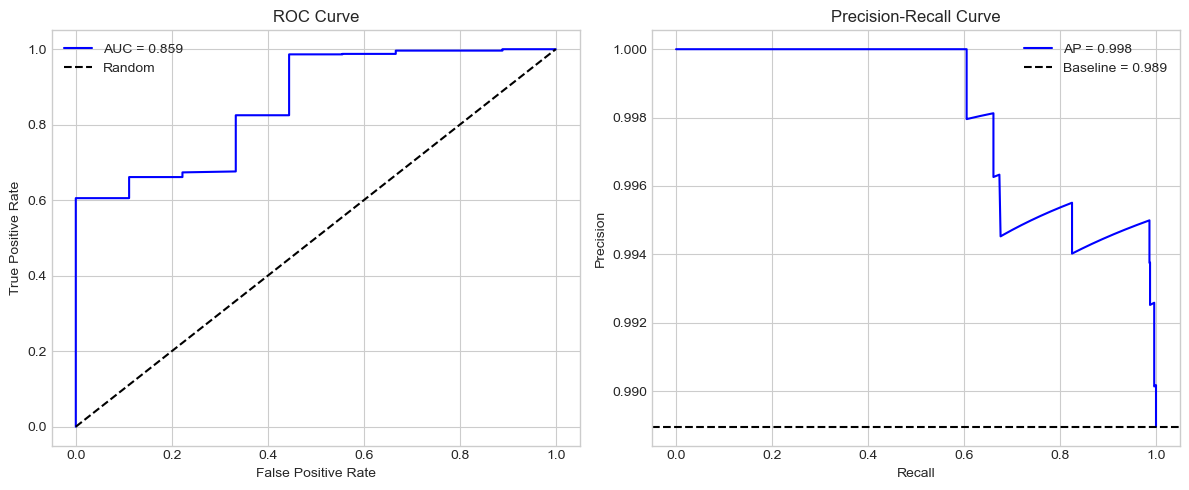

In [10]:
# ROC Curve
y_proba_test = best_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, 'b-', label=f'AUC = {test_metrics.auc_roc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
axes[1].plot(recall, precision, 'b-', label=f'AP = {test_metrics.avg_precision:.3f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/model_curves.png', dpi=150, bbox_inches='tight')
plt.show()

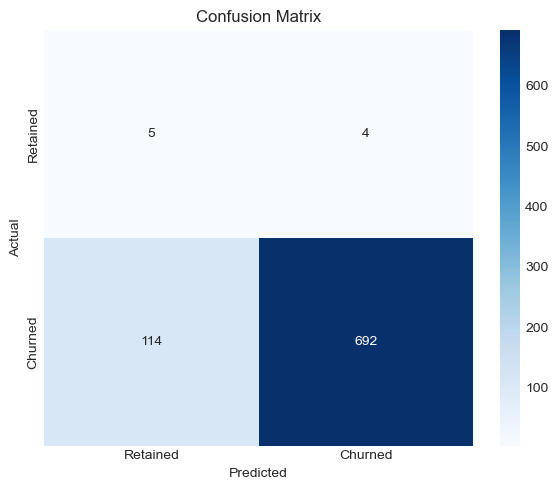

In [11]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = test_metrics.confusion_matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Calla\AppData\Local\Temp\ipykernel_3436\2623153186.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lift_agg = lift_df.groupby('decile').agg(


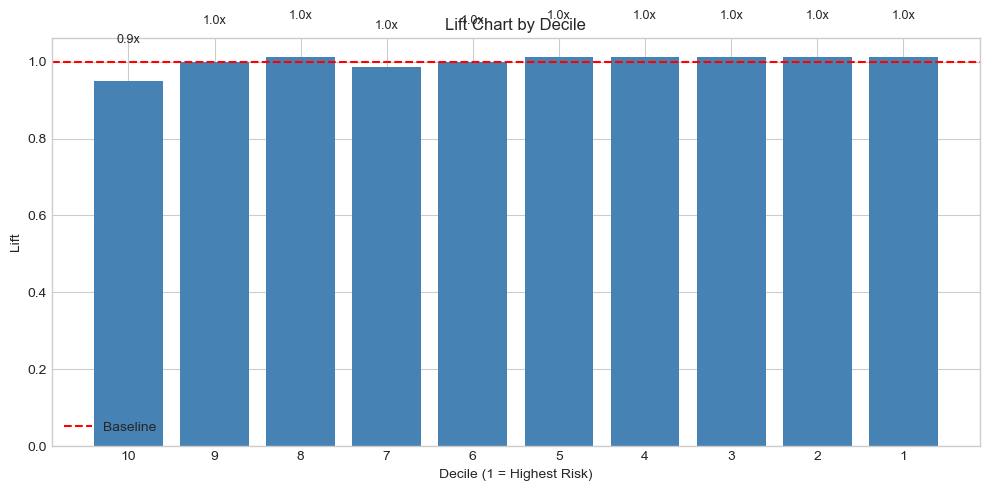

In [12]:
# Lift chart
deciles = pd.qcut(y_proba_test, q=10, labels=range(10, 0, -1), duplicates='drop')
lift_df = pd.DataFrame({'decile': deciles, 'actual': y_test.values, 'proba': y_proba_test})
lift_agg = lift_df.groupby('decile').agg(
    churn_rate=('actual', 'mean'),
    count=('actual', 'count')
).reset_index()
lift_agg['lift'] = lift_agg['churn_rate'] / y_test.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(lift_agg['decile'].astype(str), lift_agg['lift'], color='steelblue')
ax.axhline(y=1, color='red', linestyle='--', label='Baseline')
ax.set_xlabel('Decile (1 = Highest Risk)')
ax.set_ylabel('Lift')
ax.set_title('Lift Chart by Decile')
ax.legend()

# Add labels
for i, (_, row) in enumerate(lift_agg.iterrows()):
    ax.text(i, row['lift'] + 0.1, f"{row['lift']:.1f}x", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/lift_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance

In [13]:
# Get feature importance
importance_df = best_model.get_feature_importance(top_n=15)
print("Top 15 Features by Importance:")
importance_df

Top 15 Features by Importance:


,feature,importance,importance_pct
0,unique_items_transaction,3.726202,15.019780
1,transaction_count_y,2.035786,8.205958
2,view_to_purchase_rate,1.620730,6.532925
3,transaction_count_x,1.353530,5.455881
4,total_items_purchased,1.353530,5.455881
5,session_count,1.266894,5.106665
6,view_to_cart_rate,1.245547,5.020618
7,addtocart_count,1.244738,5.017359
8,unique_items_view,1.146524,4.621473
9,activity_trend,1.119546,4.512726


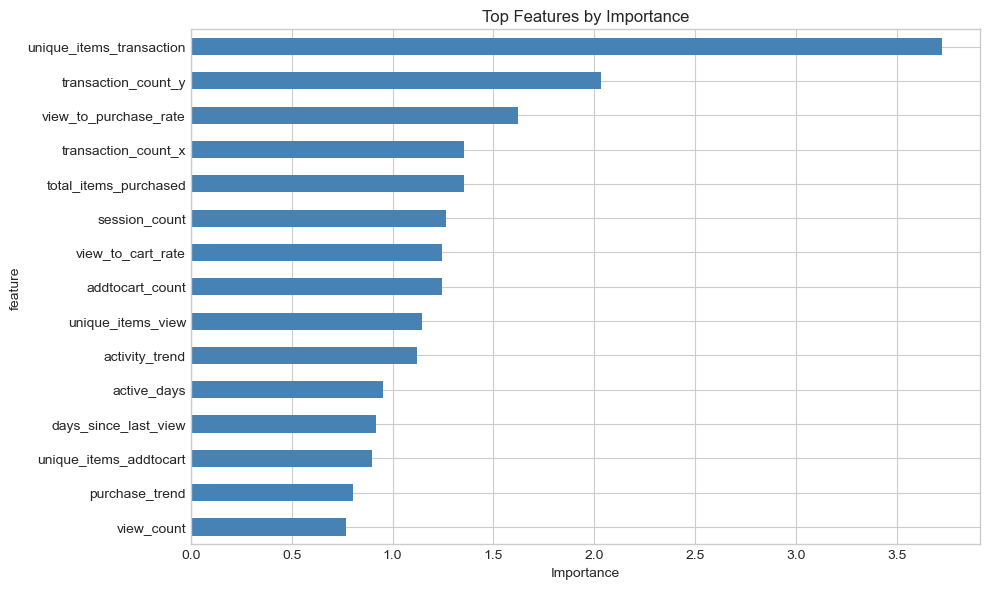

In [14]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
importance_df.plot(kind='barh', x='feature', y='importance', ax=ax, color='steelblue', legend=False)
ax.set_xlabel('Importance')
ax.set_title('Top Features by Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SHAP Analysis

In [15]:
if HAS_SHAP:
    # Compute SHAP values
    print("Computing SHAP values...")
    shap_values, explainer = best_model.get_shap_values(X_test, max_samples=500)
    print(f"SHAP values shape: {shap_values.shape}")
else:
    print("SHAP not available. Skipping SHAP analysis.")

SHAP not available. Skipping SHAP analysis.


In [16]:
if HAS_SHAP:
    # SHAP Summary Plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test.iloc[:500], feature_names=feature_cols, show=False)
    plt.title('SHAP Summary Plot')
    plt.tight_layout()
    plt.savefig('../figures/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

In [17]:
if HAS_SHAP:
    # SHAP Bar Plot (mean absolute values)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test.iloc[:500], feature_names=feature_cols,
                      plot_type='bar', show=False)
    plt.title('Mean |SHAP Value| (Average Impact on Model Output)')
    plt.tight_layout()
    plt.savefig('../figures/shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

In [18]:
if HAS_SHAP:
    # Dependence plots for top features
    top_features = importance_df['feature'].head(4).tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for ax, feat in zip(axes, top_features):
        feat_idx = feature_cols.index(feat)
        shap.dependence_plot(feat_idx, shap_values, X_test.iloc[:500],
                           feature_names=feature_cols, ax=ax, show=False)
    
    plt.tight_layout()
    plt.savefig('../figures/shap_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Model Calibration

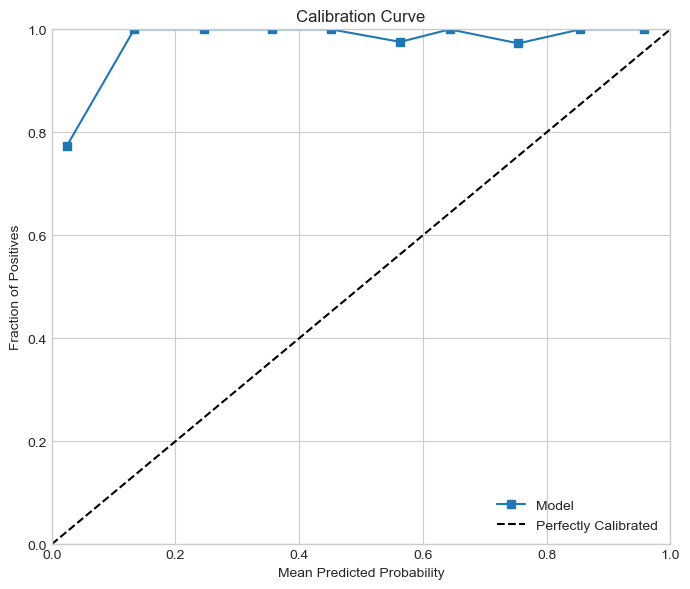

In [19]:
# Calibration curve
fraction_pos, mean_pred = best_model.get_calibration_curve(X_test, y_test, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred, fraction_pos, 's-', label='Model')
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('../figures/calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Model

In [20]:
# Save the best model
best_model.save('../data/processed/churn_model.joblib')
print("Model saved to ../data/processed/churn_model.joblib")

Model saved to ../data/processed/churn_model.joblib


In [21]:
# Save predictions for downstream use
predictions = pd.DataFrame({
    'visitorid': df['visitorid'],
    'churn_proba': best_model.predict_proba(X),
    'churned_actual': y
})
predictions.to_parquet('../data/features/churn_predictions.parquet', index=False)
print(f"Saved predictions for {len(predictions):,} customers")

Saved predictions for 5,429 customers


## 9. Key Findings

### Model Performance
- LightGBM outperforms Logistic Regression
- High lift in top deciles enables effective targeting
- Model is well-calibrated for probability estimation

### Key Predictors
1. **Recency** - Days since last purchase is most predictive
2. **Activity trend** - Declining engagement signals churn risk
3. **Engagement ratios** - Low conversion rates indicate disengagement
4. **Transaction history** - Purchase frequency indicates loyalty

### Business Implications
- Target top 20% by risk for highest ROI on retention campaigns
- Focus on customers with recent activity decline
- Intervene before recency becomes too high